# Module 4 - Machine Learning Basics

## Student Score Prediction Using Linear Regression

In this project, I will build a beginner Machine Learning model
to predict a student's score based on the number of hours studied.

The project covers:
- Machine Learning fundamentals
- Data preparation
- Train-test splitting
- Linear Regression
- Model training
- Prediction
- Model evaluation
- Data visualization

## Introduction to Machine Learning

Machine Learning (ML) is a branch of Artificial Intelligence that
enables computers to learn patterns from data and use those patterns
to make predictions or decisions.

A Machine Learning model learns from existing data and can then be
used to make predictions on new data.

### Basic Machine Learning Workflow

1. Collect or prepare data
2. Select features (X) and target (y)
3. Split the data into training and testing sets
4. Choose a Machine Learning model
5. Train the model using `model.fit()`
6. Make predictions using `model.predict()`
7. Evaluate the model's performance

### Types of Machine Learning

- **Supervised Learning:** The model learns from data with known target labels.
  - Regression: Predicts numerical values
  - Classification: Predicts categories

- **Unsupervised Learning:** The model works with data without known target
  labels and tries to discover patterns or groups.

## Supervised vs Unsupervised Learning

### Supervised Learning
Supervised Learning is a type of Machine Learning where the model
learns from data with known target labels.

Two common supervised learning tasks are:
- Regression - predicts numerical values
- Classification - predicts categories

Examples include student score prediction, house price prediction,
and flower classification.

### Unsupervised Learning
Unsupervised Learning is a type of Machine Learning where the data
does not have known target labels. The model tries to discover
patterns, similarities, or groups in the data.

A common unsupervised learning technique is clustering.

Examples include customer segmentation and grouping similar products.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT 1

In [3]:
data = {
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Score": [35, 40, 48, 52, 60, 65, 72, 78, 86, 92]
}

df = pd.DataFrame(data)

df

,Hours_Studied,Score
0,1,35
1,2,40
2,3,48
3,4,52
4,5,60
5,6,65
6,7,72
7,8,78
8,9,86
9,10,92


In [4]:
X = df[["Hours_Studied"]]

y = df["Score"]

In [6]:
X

,Hours_Studied
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [8]:
y

0    35
1    40
2    48
3    52
4    60
5    65
6    72
7    78
8    86
9    92
Name: Score, dtype: int64

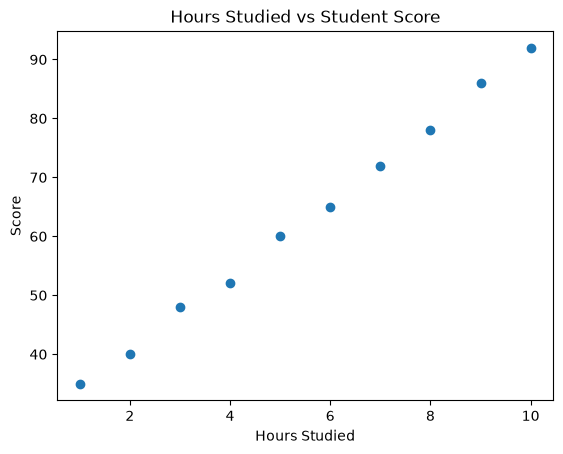

In [9]:
plt.scatter(df["Hours_Studied"], df["Score"])

plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Hours Studied vs Student Score")

plt.show()

More study hours
       ↑
Usually higher score

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 8
Testing data: 2


In [12]:
model = LinearRegression()

In [13]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[6.28]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours_Studied']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,28.23
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [14]:
y_pred = model.predict(X_test)

In [15]:
print("Predicted Scores:")
print(y_pred)

Predicted Scores:
[84.71551724 40.78448276]


In [16]:
print("Actual Scores:")
print(y_test.values)

print("Predicted Scores:")
print(y_pred)

Actual Scores:
[86 40]
Predicted Scores:
[84.71551724 40.78448276]


In [17]:
results = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred
})

results

,Actual Score,Predicted Score
0,86,84.715517
1,40,40.784483


In [18]:
new_student = pd.DataFrame({
    "Hours_Studied": [7.5]
})

predicted_score = model.predict(new_student)

print("Predicted Score:", predicted_score[0])

Predicted Score: 75.30172413793103


In [19]:
print(
    "Predicted Score for 7.5 hours of study:",
    round(predicted_score[0], 2)
)

Predicted Score for 7.5 hours of study: 75.3


In [20]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 1.0344827586206904


In [21]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 1.1326545778834771


In [22]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 1.0642624572366899


In [23]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9978588760342467


In [24]:
print("Model Evaluation")
print("----------------")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Evaluation
----------------
MAE: 1.0344827586206904
MSE: 1.1326545778834771
RMSE: 1.0642624572366899
R² Score: 0.9978588760342467


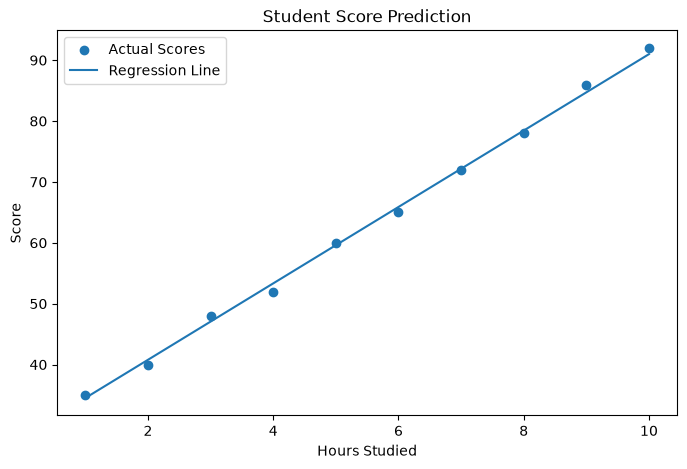

In [25]:
# Visualize the regression line

# Now let's actually see what the model learned:

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Hours_Studied"],
    df["Score"],
    label="Actual Scores"
)

plt.plot(
    df["Hours_Studied"],
    model.predict(df[["Hours_Studied"]]),
    label="Regression Line"
)

plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Student Score Prediction")
plt.legend()

plt.show()

In [26]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 6.275862068965519
Intercept: 28.232758620689644


 ## Conclusion

In this project, I built a beginner Machine Learning model to predict
student scores based on hours studied.

I used Linear Regression from Scikit-learn and learned how to:

- Prepare features and target variables
- Split data into training and testing sets
- Train a Machine Learning model
- Make predictions on test and new data
- Evaluate predictions using MAE, MSE, RMSE, and R²
- Visualize the Linear Regression model

This project helped me understand the basic Machine Learning workflow
from preparing data to training, prediction, and evaluation.

Since the dataset used in this project is very small, the model is
mainly intended for learning and demonstration rather than real-world
student score prediction.

Understand these five ideas:

X → information we give the computer (Hours Studied)

y → answer we want to predict (Score)

train_test_split() → keep some examples for learning and some for checking

model.fit() → 🤖 LEARN

model.predict() → 🤖 GUESS/PREDICT

PROJRCT 2

Classification with Iris Flowers

Previously we did:

In [27]:
from sklearn.datasets import load_iris

iris = load_iris()

In [28]:
iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

iris_df["species"] = iris.target

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [29]:
X = iris_df.drop("species", axis=1)
y = iris_df["species"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

In [32]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [33]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [34]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1
5,0,0
6,1,1
7,2,2
8,1,1
9,1,1


In [35]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


Accuracy

In [36]:
from sklearn.metrics import accuracy_score

In [38]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [39]:
print("Accuracy:", accuracy * 100, "%")

Accuracy: 100.0 %


Accuracy = Correct / Total

         = 28 / 30

         = 0.9333

         = 93.33%

Step 27 — Confusion Matrix

Accuracy tells us how many predictions were correct.

But what if we want to know which flower types the robot confused?

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


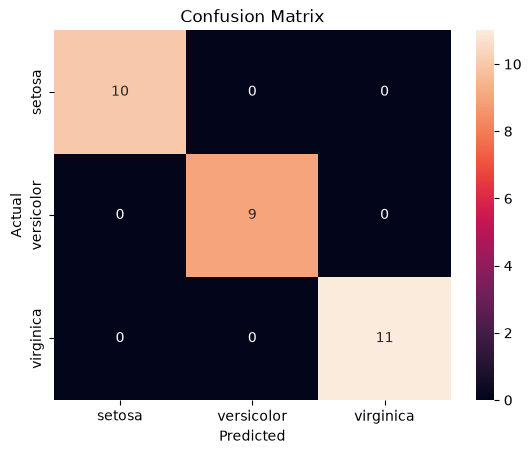

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Step 29 — Predict a NEW flower 🌸

Now let's give our trained robot a flower it hasn't seen as part of this prediction request.

Remember our four inputs:

Sepal Length
Sepal Width
Petal Length
Petal Width

In [42]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)

In [43]:
prediction = model.predict(new_flower)

print(prediction)

[0]


In [44]:
flower_name = iris.target_names[prediction[0]]

print("Predicted Flower:", flower_name)

Predicted Flower: setosa


## Supervised vs Unsupervised Learning

### Supervised Learning
Supervised learning uses training data where the correct target or
label is known. The model learns the relationship between the input
features and the target.

Examples:
- Student score prediction
- House price prediction
- Iris flower classification
- Spam email classification

Two common supervised learning tasks are:
1. Regression - predicts numerical values
2. Classification - predicts categories

### Unsupervised Learning
Unsupervised learning works with data without known target labels.
The model tries to discover patterns, similarities, or groups in the
data.

Examples:
- Customer segmentation
- Grouping similar products
- Discovering patterns in data

Clustering is a common type of unsupervised learning.

## What I Learned

In this module, I learned the basic concepts and workflow of Machine Learning.

I learned:

- What Machine Learning is
- Supervised and Unsupervised Learning
- Regression and Classification
- Features (X) and Target (y)
- Training and Testing data
- How to split data using train_test_split()
- How to train a model using model.fit()
- How to make predictions using model.predict()
- Linear Regression
- Decision Tree Classification
- Model evaluation

I also built two beginner Machine Learning models:

1. Student Score Prediction using Linear Regression
2. Iris Flower Classification using Decision Tree

## Conclusion

In Module 4, I learned the fundamentals of Machine Learning using
Scikit-learn.

I first built a Student Score Prediction model using Linear Regression
to understand regression and numerical prediction.

I then built an Iris Flower Classification model using a Decision Tree
to understand classification and categorical prediction.

I learned how to prepare features and targets, split data into training
and testing sets, train models, make predictions, and evaluate model
performance.

This module helped me understand the basic Machine Learning workflow
from data preparation to model evaluation.